# Worksheet 4.1 - State-Value Prediction with Linear State Approximation

**Learning outcomes**

1. **Identify** the **intractability** of some real-world state spaces
1. **Apply** state space representation** via a set of **features** and identify its advantages
1. **Identify** the properties of different **function approximation models** and apply them appropriately
1. **Apply** tabular **on-policy prediction methods** to **function approximation methods**


In this worksheet, we deal with function approximation to represent the states. We will use different encoding regimes. One straightforward idea is to represent the whole space as a binary vector, where each entry represents a state. Another idea is to combine multiple entries/components from multiple vectors to represent the state and more.

In [1]:
# %cd ~/rl_rob 
# !git pull

In [1]:
%matplotlib inline

In [2]:
from rl.linear import *
from env.grid.linear import *

## Approximate State Representation

In this section, we aim to vectorise the grid world used in previous units. The idea is to 
gradually move away from the tabular representation towards state-value function approximation, 
where we *approximate* each state as a vector of features. Since the grid world has a finite 
and typically small state space, this vectorisation yields a **precise** representation rather 
than an approximation — and the same applies to the corresponding value function.

However, this is only a first step towards a more general framework. In practice, we often 
cannot accurately or uniquely represent all states, and must instead compromise by prioritising 
more frequently visited or more important states — giving them greater representational power. 
This departure from preciseness into approximation is the core motivation for **Function 
Approximation Methods**.

Importantly, in this unit the state representation is **pre-specified** and fixed — it does 
**not** change during learning, which makes linear models a natural fit. In the next unit, we 
relax this assumption and allow the model to **automatically** learn state representations, at 
the cost of losing the convergence guarantees that the linear case provides.

Recall that in the tabular form, we were *estimating* the state-value function. Given a finite 
number of states, it is possible — at least in theory — to reach an exact value for all 
state-values and action-values. When we move to a vector representation, we depart from a 
finite state space to the possibility of an infinite one. Therefore, we are now *approximating* 
the state representation, and in turn *estimating an approximate* state-value and action-value 
function — hence the name **Function Approximation Methods**.

### Vectorising Grid World with One-hot Encoding

To encode a state, the corresponding component is set to 1 while all other features are set 
to 0. For example, given a state space $S = \{s_0, s_1, s_2, s_3\}$:

| State | Encoding |
|-------|----------|
| $s_0$ | $[1, 0, 0, 0]$ |
| $s_1$ | $[0, 1, 0, 0]$ |
| $s_2$ | $[0, 0, 1, 0]$ |
| $s_3$ | $[0, 0, 0, 1]$ |

Let us see how this can be done by directly inheriting from the Grid class into vGrid, which provides this representational service.

> **`vGrid`** extends `Grid` to support vectorised state representations. Instead of returning 
> a state index, `s_()` returns a feature vector $\mathbf{x}(s) \in \mathbb{R}^{n_F}$, and 
> `S_()` returns the full state matrix $X \in \mathbb{R}^{n_S \times n_F}$ — one feature 
> vector per state. By default $n_F = n_S$, yielding a one-hot encoding.

Note that we need to pass 'vGrid' as the prefix for functions that deals with the different Grid types (such as maze and ranwalk ) to return a vGrid type instead of the usual Grid type in order to get the vectorised state representation that we defined above.

In [3]:
vGrid().S_() # gives us all the state space vectors

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

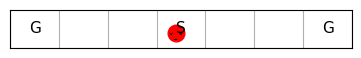

array([0., 0., 0., 1., 0., 0., 0.])

In [4]:
randwalk(vGrid).render()
randwalk(vGrid).s_() # give us current state, note that it is now a vector of values, not one value

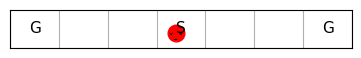

3

In [5]:
randwalk().render()
randwalk().s_()

Compare the return of the above calls, in the vGrid we obtained a vector that represents the current state while in the Grid we get the index of the current state. 

We can also define a vrandwalk to be a vectroised random walk grid as follows.

In [6]:
def vrandwalk(**kw):  return randwalk  (vGrid, **kw)
def vrandwalk_(**kw): return randwalk_ (vGrid, **kw)
def vgrid(**kw):      return grid      (vGrid, **kw)
def vmaze(**kw):      return maze      (vGrid, **kw)
def vcliffwalk(**kw): return cliffwalk (vGrid, **kw)
def vwindy(**kw):     return windy     (vGrid, **kw)

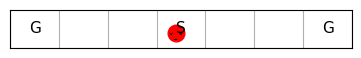

array([0.        , 0.16666667, 0.33333333, 0.5       , 0.66666667,
       0.83333333, 1.        ])

In [7]:
vrandwalk().render()
vrandwalk().s_()
vrandwalk().Vstar

# Prediction with Function Approximation

## MRP with Linear Function Approximation

In a linear model, we devise — customary to linear regression — a weight vector of the same 
size as the feature vector, where each weight corresponds to a feature. We defer treatment of 
the bias term until it becomes necessary.

For any linear representation, the value function is given by:

$$V(s) = \mathbf{w}^\top \mathbf{x}$$

The weight update follows the same principle as in the tabular case, but now uses a dot product 
rather than a table lookup. Specifically, the gradient of $V(s)$ with respect to $\mathbf{w}$ 
is simply $\mathbf{x}$, which makes the update rule clean and efficient.

In one-hot encoding, each weight directly corresponds to the value of the matching state — 
so the weight vector *is* the value function. This means we should recover results identical 
to those obtained in the tabular setting for problems such as the random walk, the maze, and 
the cliff walk.

> **`vMRP`** extends `MRP` to support linear function approximation. Instead of a value table, 
> it maintains a weight vector $\mathbf{w} \in \mathbb{R}^{n_F}$, and the value function is 
> computed as $V(s) = \mathbf{w}^\top \mathbf{x}(s)$. The gradient $\Delta V(s) = \mathbf{x}(s)$ 
> is used to update the weights during learning. Note that we could not use the actual $\nabla$ and instead used the closest symbole which $\Delta$

## Gradient MC with Function Approximation

Recall from the lesson that the weight update is:

$$\mathbf{w} \leftarrow \mathbf{w} + \alpha \left(G_t - V(s)\right) \mathbf{x}(s)$$

> **`vMC`** extends `vMRP` with offline Monte Carlo learning. At the end of each episode, it 
> traverses the trajectory in reverse to compute the return $G_t$ and applies the update above. 
> This is the direct linear function approximation analogue of the tabular MC method.

In [8]:
class vMC(vMRP):
    def init(self):
        self.store = True 
        
    # ----------------------------- 🌘 offline, MC learning: end-of-episode learning ----------------------    
    def offline(self):
        # obtain the return for the latest episode
        Gt = 0
        for t in range(self.t, -1, -1):
            s = self.s[t]
            rn = self.r[t+1]
            
            Gt = self.γ*Gt + rn
            self.w += self.α*(Gt - self.V(s))*self.ΔV(s)


This definition is almost identical to its tabular counterpart, with three key differences:

1. We update a weight vector $\mathbf{w}$ rather than a single table entry — hence $\mathbf{w}$ 
   on the left-hand side instead of $V[s]$.
2. We use $V(\cdot)$ instead of $V[\cdot]$ on the right-hand side, reflecting that the value 
   function is now computed via a dot product rather than a table lookup.
3. We multiply by the gradient $\nabla V(s) = \mathbf{x}(s)$, provided by the `vMRP` parent class.

Note that $\mathbf{x}(s)$ here is the feature vector representing state $s$, not a scalar index.

Importantly, although `vMRP` assumes linear function approximation, `vMC` does not — it only 
requires that the parent class provides $\nabla V(s)$. This means we can swap in any other 
approximation scheme (tile coding, neural networks, etc.) simply by defining a new parent class, 
without touching the `vMC` definition. For more details, refer to Section 9.3 of the textbook.

We now apply the gradient vMC algorithm to the random walk problem using one-hot encoding.

mcwalk= MC(env=randwalk(), episodes=20, plotV=True, plotE=True, seed=1).interact()

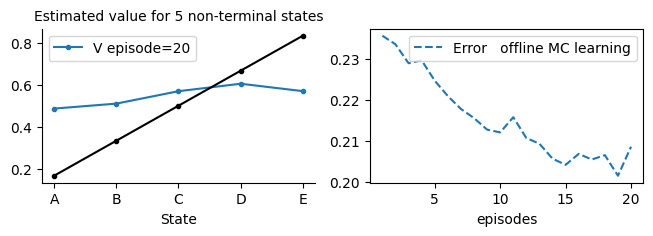

In [9]:
vmcwalk = vMC(env=vrandwalk(), α=.01, episodes=20, v0=.5, seed=0, **demoE).interact(label='offline MC learning')

## Online Semi-Gradient TD with Linear Function Approximation

In [10]:
class vTD(vMRP):
    # ----------------------------- 🌖 online learning ----------------------    
    def online(self, s, rn,sn, done, *args): 
        self.w += self.α*(rn + (1-done)*self.γ*self.V(sn) - self.V(s))*self.ΔV(s)

> **`vTD`** extends `vMRP` with online TD learning. At each step, it updates the weights using:
>
> $$\mathbf{w} \leftarrow \mathbf{w} + \alpha \left(r + \gamma V(s') - V(s)\right) \mathbf{x}(s)$$

This is the **semi-gradient** TD update — we apply the gradient to $V(s)$ but treat the target 
$V(s')$ as fixed. This is consistent with MC, which serves as the theoretical baseline for TD. 
Algorithms that take the full gradient of both terms exist but tend to converge more slowly than 
semi-gradient TD, particularly with linear function approximation. Refer to Section 9.3 of the 
textbook for more details.

As with `vMC`, the `vTD` class does not assume linear function approximation — it only requires 
that the parent class provides $\nabla V(s)$. This means we can substitute any approximation 
scheme (tile coding, neural networks, etc.) by simply changing the parent class, leaving `vTD` 
untouched. We exploit this modularity via a class factory when needed.

We now apply the semi-gradient TD algorithm to the random walk problem using one-hot encoding.

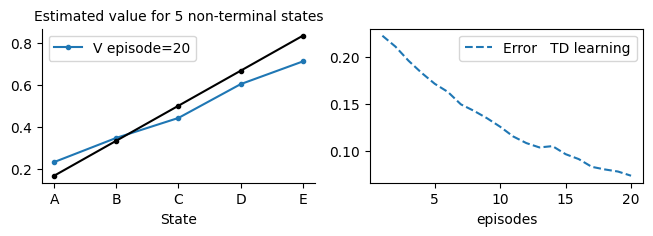

In [11]:
TDwalk = vTD(env=vrandwalk(), episodes=20, v0=.5, **demoE).interact(label='TD learning')

We need to pass the env explicitly because we have inherited the MRP and the new environment would have no took effect.

## Offline Semi-Gradient TD with Function Approximation

> **`vTDf`** extends `vMRP` with offline TD learning. Rather than updating at each step, it 
> stores the full episode trajectory and applies the same semi-gradient update as `vTD` at the 
> end of each episode. The key distinction from MC is that it still uses bootstrapping — it does 
> not rely on the full actual return $G_t$ — which reduces variance at the cost of some bias, 
> yet in practice tends to outperform MC. This makes it the offline analogue of `vTD`, useful 
> for comparing online versus offline learning behaviour.

In [12]:
class vTDf(vMRP):
    
    def init(self):
        self.store = True
        
    # ----------------------------- 🌘 offline TD learning ----------------------------   
    def offline(self):
        for t in range(self.t, -1, -1):
            s = self.s[t]
            sn = self.s[t+1]
            rn = self.r[t+1]
            done = self.done[t+1]
            
            self.w += self.α*(rn + (1-done)*self.γ*self.V(sn) - self.V(s))*self.ΔV(s)


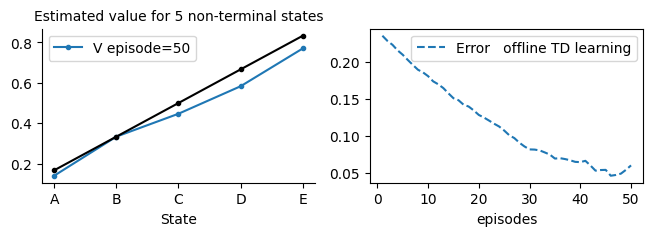

In [13]:
tdwalk = vTDf(env=vrandwalk(), α=.05, episodes=50, v0=.5, **demoE).interact(label='offline TD learning')

Let us rerun example 6.2 to double-check that our algorithm is working well. This time, we are using a vectorised grid and a linear model for TD and MC.

100%|██████████████████████████████████████████████████████████████████████████████████████████|100/100
100%|██████████████████████████████████████████████████████████████████████████████████████████|100/100
100%|██████████████████████████████████████████████████████████████████████████████████████████|100/100
100%|██████████████████████████████████████████████████████████████████████████████████████████|100/100
100%|██████████████████████████████████████████████████████████████████████████████████████████|100/100
100%|██████████████████████████████████████████████████████████████████████████████████████████|100/100
100%|██████████████████████████████████████████████████████████████████████████████████████████|100/100


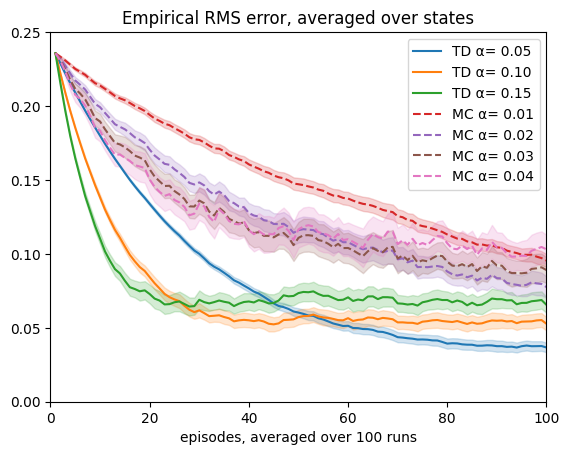

In [14]:
# running the book example 6.2, which compares TD and MC on a random walk, but this time we use vector representation
example_6_2(env=vrandwalk(), alg1=vTDf, alg2=vMC)

##  One-hot-encoding with redundant features for prediction
As an auxiliary step towards generalising our classes to deal with any linear function approximation, below we create a random walk problem with 1000 redundant features to test whether our infrastructure classes are working.

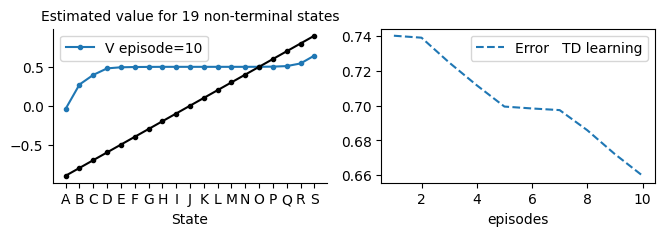

In [15]:
vTDwalk = vTD(env=vrandwalk_(nF=100), episodes=10, v0=.5, seed=10, **demoE).interact(label='TD learning')

## State Representation: State aggregation


$\underbrace{\{s_0\}}_{F_0}, \underbrace{\{s_1, s_2, ..., s_{100}\}}_{F_1}, \underbrace{\{s_{101}, s_{102}, ..., s_{200}\}}_{F_2},...,  \underbrace{\{s_{901}, s_{902}, ..., s_{1000}\}}_{F_{10}}, \underbrace{\{s_{1001}\}}_{F_{11}},$


For the state aggregation to work as intended, the goals must have a separate state representation from the groups; hence we dedicate the first and the last components for these two terminal states as we have shown above (or even put both of them in the same component). We then divide the non-goal states into 100, where each 100 are represented via a component and whenever the agent is at any of the 100 states the corresponding component will be on and all other components are off. 


## State Aggregation

Recall from the lesson that state aggregation generalises one-hot encoding by grouping states 
into tiles, where each feature represents a group rather than a single state:

$$F_i: \underbrace{\{s_0, s_1, ..., s_{99}\}}_{F_0}, \underbrace{\{s_{100}, ..., s_{199}\}}_{F_1},\ldots,\underbrace{\{s_{900}, ..., s_{999}\}}_{F_9}$$

A feature is set to 1 whenever the agent is in **any** state within the corresponding group, 
and 0 otherwise. For example, if the agent is in $s_{150}$, the feature vector is 
$\mathbf{x} = [0,1,0,0,0,0,0,0,0,0]$.

Terminal states are handled implicitly — our algorithms multiply the next state's value by 
$(1 - \text{done})$, which sets it to 0 at termination, so no separate component is needed.

The group size is controlled by **`tilesize`** — larger tiles mean fewer features and coarser 
approximation. In 1D (random walk) we have 1D tiles; in a grid we have 2D tiles. Refer to 
Example 9.2 in the textbook for more details.

> **`aggGrid`** extends `vGrid` with state aggregation. It groups states into tiles of size 
> **`tilesize`**, reducing the feature space from $n_S$ to $\lceil n_S / \text{tilesize} \rceil$ 
> components. The feature vector $\mathbf{x}(s)$ is a one-hot vector with the active component 
> determined by $\lfloor s / \text{tilesize} \rfloor$.

In [16]:
class aggGrid(vGrid):
    def __init__(self, tilesize=1, **kw):
        super().__init__(**kw)
        self.tilesize = self.jump = tilesize
        self.nF = -(-self.nS//self.tilesize)
        
    def s_(self):
        φ = np.zeros(self.nF) 
        φ[self.s//self.tilesize] = 1 
        return φ

As we can see, we have encoded the states via our s_( ) function which uses one-hot encoding. 
The index is specified via the aggregation which is achieved by using the //tilesize operation.

### 1000-State Random Walk with Jumps

To speed up state transitions and align with state aggregation, we use `aggGrid`, which 
inherits from `vGrid` → `Grid`, allowing the agent to jump multiple states at a time. 
`vGrid` also provides `S_()`, needed to evaluate $V(s)$ across all states.

In the example below, we allow random jumps of up to 100 steps and aggregate states into 
groups of 50, yielding 20 features — mirroring the 19 non-terminal states of the random 
walk problem seen in previous lessons:

$$\underbrace{\{s_0, \ldots, s_{49}\}}_{F_0},\ \underbrace{\{s_{50}, \ldots, s_{99}\}}_{F_1},\ \ldots,\ \underbrace{\{s_{950}, \ldots, s_{999}\}}_{F_{19}}$$

In [17]:
# assuming that vstar is a function that returns Vstar values
def aggrandwalk_(nS=1000, tilesize=50, vstar=None, **kw): 
    env = randwalk_(aggGrid, nS=nS, tilesize=tilesize, **kw)
    if vstar is not None: env.Vstar = vstar(env) # vstar is a function
    return env

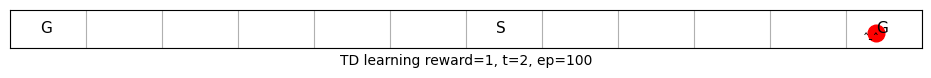

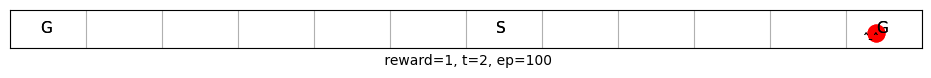

In [18]:
aggTDwalk = vTD(env=aggrandwalk_(nS=12, tilesize=4, figsize=[40,.5], jump=4), 
                 episodes=100, v0=.5, seed=10, visual=True).interact(label='TD learning', pause=.5)

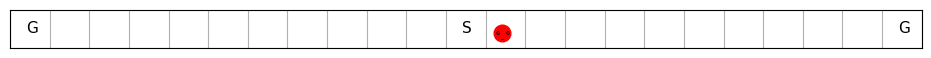

In [19]:
env = aggrandwalk_(nS=23, tilesize=3, figsize=[40,.5])
env.render(pause=1)
env.jump=3
env.step(1)
env.render()

Let us now apply our online TD on a 25 state aggregation problem with 5 groups.

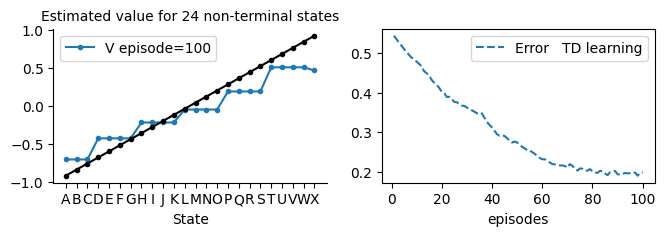

In [20]:
aggTDwalk = vTD(env=aggrandwalk_(nS=24+2, tilesize=4),α=.05, episodes=100, v0=.0, seed=10, **demoE).interact(label='TD learning')

## n-step TD with linear function approximation

> **`vTDn`** extends `vMRP` with online $n$-step semi-gradient TD learning. At each step, it 
> waits $n-1$ steps before updating the weights using the $n$-step return $G_{t:t+n}$ as the 
> target:
>
> $$\mathbf{w} \leftarrow \mathbf{w} + \alpha \left(G_{t:t+n} + \gamma^n V(s_{t+n}) - V(s_t)\right) \mathbf{x}(s_t)$$
>
> It generalises `vTD` ($n=1$) and approaches `vMC` as $n \rightarrow \infty$.

In [21]:
class vTDn(vMRP):

    def init(self):
        self.store = True # there is a way to save storage by using t%(self.n+1) but we left it for clarity

    # ----------------------------- 🌖 online learning ----------------------    
    def online(self,*args):
        τ = self.t - (self.n-1);  n=self.n
        if τ<0: return
        
        # we take the min so that we do not exceed the episode limit (last step+1)
        τn = τ+n ; τn=min(τn, self.t+1 - self.skipstep)
        τ1 = τ+1
        
        sτ = self.s[τ ]
        sn = self.s[τn]
        done = self.done[τn]
        
        # n steps τ+1,..., τ+n inclusive of both ends
        self.w += self.α*(self.G(τ1,τn)+ (1-done)*self.γ**n *self.V(sn) - self.V(sτ))*self.ΔV(sτ)
        


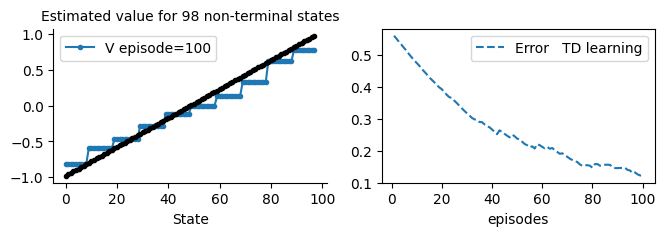

In [22]:
# try increase nS to 102+2 to see the effect
aggTDwalk = vTDn(env=aggrandwalk_(nS=100, tilesize=10), α=.02, n=4, episodes=100, v0=.0, seed=10, **demoE).interact(label='TD learning')

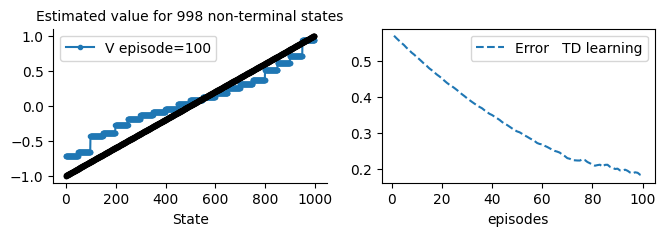

In [23]:
aggTDwalk = vTDn(env=aggrandwalk_(), α=.01, n=10, episodes=100, v0=.0, seed=0, **demoE).interact(label='TD learning')

Note that we had to reduce the learning rate α because the increased number of steps entails more updates and hence larger update magnitude.

## Solving the 1000 Random Walk via Dynamic Programming(DP)

The staircase pattern appearing slightly off is not a flaw in `vTDn` — it is in the reference 
solution $V^*$ (the straight line), which was derived for the random walk *without* jumps and 
is therefore no longer exact, albeit a close approximation.

To obtain a more accurate reference, we can delegate the problem to a Dynamic Programming 
solver. Below we apply the policy evaluation method from Lesson 3 — appropriate here since 
we are dealing with prediction under a stationary policy (equal probability of jumping left 
or right). This will reveal how much the true solution shifts when jumps are introduced.

In [24]:
def DP(env=aggrandwalk_(), compare=False, θ=1e-2):
    π = np.ones((env.nS, env.nA), dtype=np.uint32)*.5
    Vstar = policy_evaluation(env=env, π=π, V=env.Vstar, θ=θ, show=False)
    print('V* obtained')
    if compare:
        plt.plot(env.Vstar,   label='solution for 1000-random walk without jumps')
        plt.plot(Vstar[1:-1], label='solution for 1000-random walk with    jumps')
        plt.legend()
    return Vstar

Let us compare the default straight line solution to the V* solution for the random walk problem when we employ the jumping procedure. This will take a couple of minutes so please wait for it.

100%|█████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.05it/s]


V* obtained


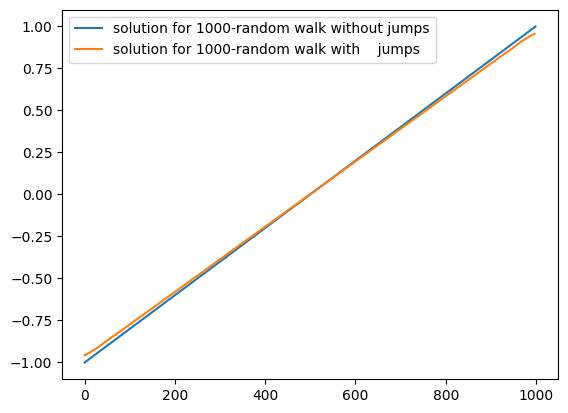

In [25]:
aggVstar = DP(env=aggrandwalk_(), compare=True)

The two solutions are close but not identical. Decreasing $\theta$ yields a more accurate DP 
estimate — the blue line will bend further toward the true solution — but at the cost of longer 
computation, illustrating one of the key limitations of DP compared to more scalable RL 
algorithms such as TD.

**Group exercise:** Set $\theta = 10^{-3}$, record how long the algorithm takes to converge, 
and share your result in the group discussion.

## Solving the 1000 Random Walk with Online n-step TD with linear function approximation and state aggregation

We can integrate finding a DP solution with the comparison as below, but since we have already found a solution in the previous steps we can simply also utilise the solution for comparison directly as we do in subsequent cells. Note that the level of accuracy, specified in θ, can be adjusted. 

100%|█████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.48it/s]


V* obtained
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|█████████████████████████████████████████████████████████████████

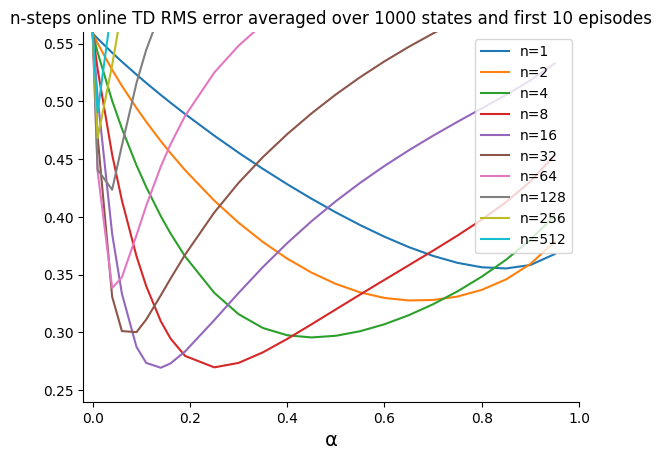

In [26]:
%time nstepTD_MC_randwalk_αcompare(env=aggrandwalk_(vstar=DP), algorithm=vTDn, runs=10, envlabel='1000', MCshow=False)

In [27]:
# %time nstepTD_MC_randwalk_αcompare(env=aggrandwalk_(Vstar=aggVstar), algorithm=vTDn, runs=10, envlabel='1000', MCshow=False)

## Offline n-step TD with linear function approximation

> **`vTDnf`** extends `vMRP` with offline $n$-step semi-gradient TD learning. It stores the 
> full episode trajectory and sweeps through it at the end, applying the same $n$-step update 
> as `vTDn`. It is the offline analogue of `vTDn`, useful for comparing online versus offline 
> $n$-step learning behaviour.

In [28]:
class vTDnf(vMRP):

    def init(self):
        self.store = True # offline method we need to store anyway

    # ----------------------------- 🌘 offline TD learning ----------------------------   
    def offline(self):
        n = self.n        
        for t in range(self.t+n): # T+n to reach T+n-1
            τ  = t - (n-1)
            if τ<0: continue
        
            # we take the min so that we do not exceed the episode limit (last step+1)
            τ1 = τ+1
            τn = τ+n ; τn=min(τn, self.t+1)
            
            sτ = self.s[τ ]
            sn = self.s[τn]
            done = self.done[τn]
            
            # n steps τ+1,..., τ+n inclusive of both ends
            self.w += self.α*(self.G(τ1,τn)+ (1-done)*self.γ**n *self.V(sn) - self.V(sτ))*self.ΔV(sτ)

## Solving the 1000 with Offline n-step TD with linear function approximation and state aggregation

100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
15%|█████████████|5/32

/var/folders/5s/t5nyc5mx7gd0_0g56wdmpgmrq78pqs/T/ipykernel_41350/4034261480.py:22: RuntimeWarning: invalid value encountered in multiply
  self.w += self.α*(self.G(τ1,τn)+ (1-done)*self.γ**n *self.V(sn) - self.V(sτ))*self.ΔV(sτ)


100%|██████████████████████████████████████████████████████████████████████████████████████████|32/32
CPU times: user 1h 26min 56s, sys: 47min 56s, total: 2h 14min 53s
Wall time: 18min 9s


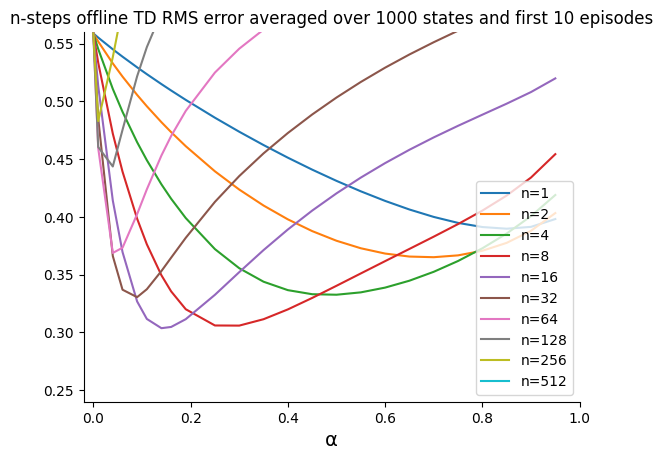

In [29]:
%time nstepTD_MC_randwalk_αcompare(env=aggrandwalk_(Vstar=aggVstar),\
                                   algorithm=vTDnf, runs=10, alglabel='offline TD', envlabel='1000', MCshow=False)

## State Representation: Tile Coding

Recall from the lesson that tile coding extends state aggregation by partitioning the state 
space **multiple times**. Each partition is called a **tiling**, and each tiling consists of 
$n$ **tiles**. With $d$ tilings, the full feature vector has length $d \times n$, with exactly 
$d$ components active for any given state.

Each tiling is offset (shifted) from the previous one — similar to strides in CNNs — creating 
overlapping partitions that allow finer discrimination between states than a single aggregation 
could achieve. For example, with $d=3$ tilings of $n=5$ tiles each:

$$\underbrace{\{s_0, \ldots, s_{199}\}}_{F_{0,0}},\ \ldots,\ \underbrace{\{s_{800}, \ldots, s_{999}\}}_{F_{4,0}}$$
$$\underbrace{\{s_1, \ldots, s_{200}\}}_{F_{0,1}},\ \ldots,\ \underbrace{\{s_{801}, \ldots, s_{999}\}}_{F_{4,1}}$$
$$\underbrace{\{s_2, \ldots, s_{201}\}}_{F_{0,2}},\ \ldots,\ \underbrace{\{s_{802}, \ldots, s_{999}\}}_{F_{4,2}}$$

So if the agent is in state $s_{200}$, its tile coding representation is:

$$\mathbf{x} = [0, 1, 0, 0, 0,\ \ 1, 0, 0, 0, 0,\ \ 1, 0, 0, 0, 0]$$

When memory is a concern, tile coding can be combined with **hashing** to reduce the feature 
vector size below $d \times n$.

In [30]:
class tiledGrid(vGrid):
    def __init__(self, ntilings, offset=4, tilesize=50, **kw):
        super().__init__(**kw)
        self.tilesize = self.jump = tilesize
        self.ntilings = ntilings
        self.offset = offset
        self.ntiles = -(-self.nS//self.tilesize) 
        self.nF = self.ntiles*self.ntilings
    
    def s_(self):
        φ = np.zeros((self.ntilings, self.ntiles))
        
        for tiling in range(self.ntilings):
            ind = min((self.s + tiling*self.offset)//self.tilesize, self.ntiles-1)
            φ[tiling, ind] = 1
            
        return φ.flatten()

Let us now define a tiled random walk environment with 1000 states handy to be used in our next set of experiments. As usual it has a rewards of (-1,1) for the far left and far right states while it has a tile size of 200. We can use multiple tilings for it to cover its states. We will use our original guess as the optimal Vstar estimation for the state values,however we will allow Vstar to be assigned a more correct values based on DP.

In [31]:
def tiledrandwalk_(nS=1000, ntilings=1, tilesize=200, vstar=None, **kw):
    env = randwalk_(tiledGrid, nS=nS, ntilings=ntilings, tilesize=tilesize,  **kw)
    if vstar is not None: env.Vstar = vstar(env) 
    return env

### Studying the Effect of Number of Tilings
Below we run the tiled random walk problem with different number of tilings to show there effect.

In [32]:
def TDtiledwalk(ntilings):
    env=tiledrandwalk_(nS=20, tilesize=4, offset=1, ntilings=ntilings)
    vTD(env=env, α=.02, episodes=200, **demoE).interact(label='TD learning, %d tilings'%ntilings)

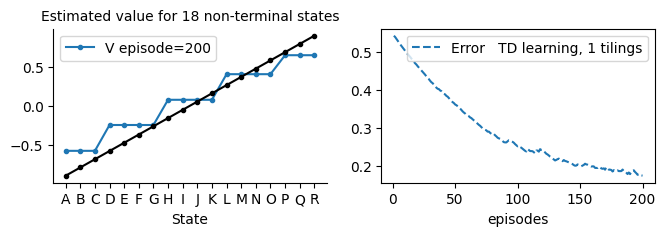

In [33]:
TDtiledwalk(ntilings=1)

TDtiledwalk(ntilings=2)

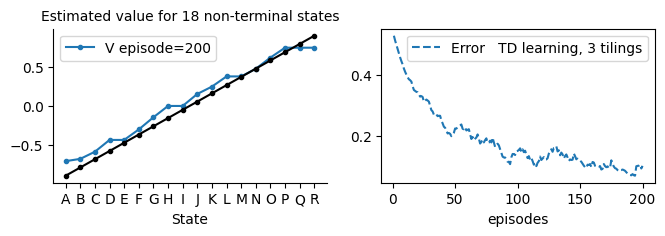

In [34]:
TDtiledwalk(ntilings=3)

TDtiledwalk(ntilings=4)

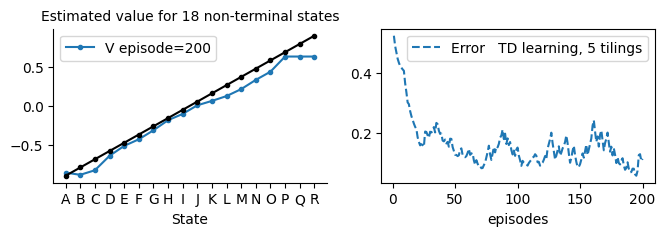

In [35]:
TDtiledwalk(ntilings=5)

Note how the increased number of tilings enhanced the estimation and reduced the error and the values become smoother with less stair-style effect. So in fact ntilings has a smoothening effect on the value function and helps to improve the estimation of our algorithms. 

### TD on 1000 Tiled Coded Random Walk

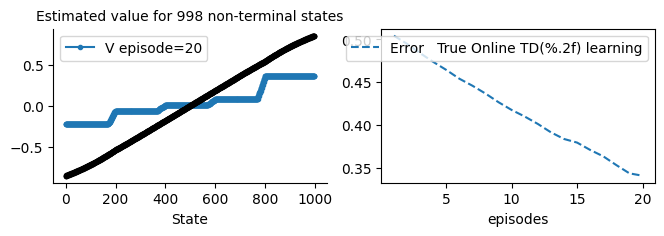

In [36]:
TDwalk = vTD(env=tiledrandwalk_(ntilings=8, Vstar=DP(tiledrandwalk_())),α=.005, episodes=20, **demoE).interact(label='True Online TD(%.2f) learning')

When using function approximation, the objective is the squared error (SE) rather than RMSE — 
chosen because it is easily differentiable, which is what the gradient update requires. We can 
still use RMSE as a performance *metric*, as in previous lessons, even though we optimise SE 
during training.

Below we reproduce Figure 9.10 from the textbook, comparing 1 tiling against 50 tilings on 
the tiled random walk. We use Monte Carlo since it is a full-gradient algorithm — the target 
$G_t$ involves no next-step estimate, avoiding the semi-gradient approximation. TD could be 
used here as well.

First, we compute $V^*$ for the 200-jump variant of the problem, as the earlier solution was 
derived for 50 jumps and is no longer valid here.

In [37]:
def vMCtilingsRuns():
    Vstar=DP(tiledrandwalk_(),θ=1e-3)
    for ntilings in [1, 50]:
        env=tiledrandwalk_(ntilings=ntilings, tilesize=200, Vstar=Vstar)
        α =.001/ntilings
        mcs = Runs(algorithm=vMC(env=env,α=α, episodes=500), v0=0, 
                   runs=10, plotE=True).interact(label='MC with %d tilings'%ntilings)
    plt.ylim(0,.45)

figure_9_10 = vMCtilingsRuns 

100%|█████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.43s/it]


V* obtained
100%|██████████████████████████████████████████████████████████████████████████████████████████|10/10
100%|██████████████████████████████████████████████████████████████████████████████████████████|10/10


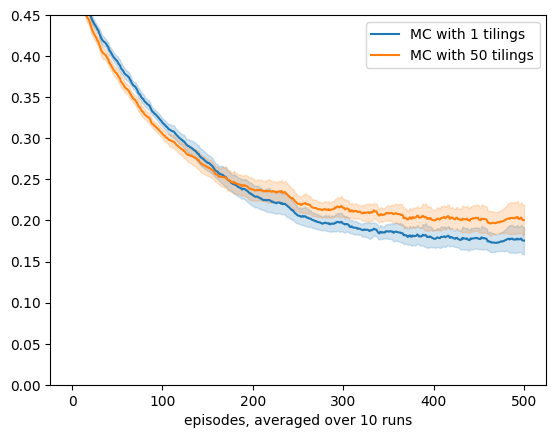

In [38]:
figure_9_10()

This figure takes a long time to produce due to the extensivity of the experiments. As we can see, adding more tilings further reduced the error of the value function estimation and hence enhanced the algorithm's performance.

## Conclusion

In this worksheet we explored function approximation in the context of reinforcement learning. 
We moved gradually from tabular representations toward parametric models, covering one-hot 
encoding, state aggregation, and tile coding as progressively richer state representations. 
We then saw how standard prediction algorithms — MC, TD, and $n$-step TD — generalise 
naturally to this setting via the semi-gradient update rule, with the key insight that only 
the gradient of the current state estimate $V(s)$ is taken, leaving the target fixed.

## Your Turn

1. In `TDtiledwalk()`, reduce the learning rate proportionally to the number of tilings, 
   e.g. $\alpha = 0.02 / \text{ntilings}$. Adjust the code and observe the effect on 
   convergence.

2. You may have notices that with tile coding, the weight update does not require a full dot product — 
   only the active tiles need updating. Can you think of how to exploit this for state 
   aggregation? What does the update rule simplify to in that case?

3. Use tile coding with Sarsa on a grid world problem and compare the learning behaviour 
   against the tabular case.